# Imports

In [198]:
## Processing
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder
import math
import pyreadstat
from haversine import haversine_vector
import warnings
from sklearn import linear_model
from scipy import stats
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

## Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import geopandas as gpd
from geopandas import GeoDataFrame
from shapely.geometry import Point

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (7, 7)
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

##### Resources

https://datascience.stackexchange.com/questions/49553/combining-latitude-longitude-position-into-single-feature


https://python.plainenglish.io/south-africa-crime-data-visualization-e938eb4d293d

https://www.researchgate.net/post/How_can_I_combine_different_Likert_scales_into_one_overall_measure#:~:text=The%20most%20straightforward%20way%20to,(equivalently)%20take%20an%20average

https://www.scribbr.com/methodology/likert-scale/#:~:text=A%20Likert%20scale%20is%20a,about%20the%20statement%20or%20question

https://medium.com/analytics-vidhya/finding-nearest-pair-of-latitude-and-longitude-match-using-python-ce50d62af546

# Data

## GDELT Protests Data

In [200]:
# dtafile = './saprotests.dta'
# df, meta = pyreadstat.read_dta(dtafile)

In [201]:
# df.head()

In [202]:
# Read in the GDELT Protests dataframe
df = pd.read_csv(r'C:\Users\danie\OneDrive\Desktop\GDELT Protests South Africa.csv')

In [203]:
df.head()

,GlobalEventID,MonthYear,ActionGeo_Long,ActionGeo_Lat
0,885731620,201911,19.6663,-33.4771
1,885731629,201911,19.6663,-33.4771
2,885775267,201911,27.8672,-26.2234
3,776780306,201808,29.9924,-22.3708
4,776755077,201808,18.4955,-34.0289


In [204]:
df.describe()

,GlobalEventID,MonthYear,ActionGeo_Long,ActionGeo_Lat
count,7.795200e+04,77952.000000,77952.000000,77952.000000
mean,7.945554e+08,201861.783610,26.550999,-28.613946
std,1.688157e+08,195.815998,3.805431,3.037099
min,4.986048e+08,201601.000000,16.461700,-34.822300
25%,6.431100e+08,201703.000000,26.000000,-30.000000
50%,8.022435e+08,201811.000000,28.083300,-27.881800
75%,9.505247e+08,202010.000000,28.250000,-26.111700
max,1.123572e+09,202212.000000,33.533300,-22.184600


In [205]:
# Rename the 'ActionGeo_Long' column to 'GDELT_Long'
df = df.rename(columns={'ActionGeo_Long': 'GDELT_Long'})

# Rename the 'ActionGeo_Lat' column to 'GDELT_Lat'
df = df.rename(columns={'ActionGeo_Lat': 'GDELT_Lat'})

# Rename the 'MonthYear' column to 'Year'
df = df.rename(columns={'MonthYear': 'Year'})

In [206]:
# Remove the months from MonthYear
df['Year'] = df['Year'].astype(str)
df['Year'] = df['Year'].str[:-2]
df['Year'] = df['Year'].astype(int)

In [207]:
# Implement the Haversine Formula
def single_pt_haversine(lat, lng, degrees=True):
    """
    'Single-point' Haversine: Calculates the great circle distance
    between a point on Earth and the (0, 0) lat-long coordinate
    """
    r = 6371 # Earth's radius (km)

    # Convert decimal degrees to radians
    if degrees:
        lat, lng = map(math.radians, [lat, lng])

    # 'Single-point' Haversine formula
    a = math.sin(lat/2)**2 + math.cos(lat) * math.sin(lng/2)**2
    d = 2 * r * math.asin(math.sqrt(a)) 

    return d

In [208]:
# Get the Haversine distance for GDELT data
df['GDELT_Haversine'] = [single_pt_haversine(GDELT_Lat, GDELT_Long) 
                         for GDELT_Lat, GDELT_Long in zip(df.GDELT_Lat, df.GDELT_Long)]

In [209]:
# Drop duplicates from GDELT_Haversine
df = df.drop_duplicates(subset=["GlobalEventID"], keep='first')

In [210]:
df.head()

,GlobalEventID,Year,GDELT_Long,GDELT_Lat,GDELT_Haversine
0,885731620,2019,19.6663,-33.4771,4251.817764
1,885731629,2019,19.6663,-33.4771,4251.817764
2,885775267,2019,27.8672,-26.2234,4173.016154
3,776780306,2018,29.9924,-22.3708,4090.075635
4,776755077,2018,18.4955,-34.0289,4246.697089


In [211]:
df.describe()

,GlobalEventID,Year,GDELT_Long,GDELT_Lat,GDELT_Haversine
count,7.795200e+04,77952.000000,77952.000000,77952.000000,77952.000000
mean,7.945554e+08,2018.554020,26.550999,-28.613946,4284.583621
std,1.688157e+08,1.956888,3.805431,3.037099,182.058045
min,4.986048e+08,2016.000000,16.461700,-34.822300,3609.200387
25%,6.431100e+08,2017.000000,26.000000,-30.000000,4176.066812
50%,8.022435e+08,2018.000000,28.083300,-27.881800,4196.953512
75%,9.505247e+08,2020.000000,28.250000,-26.111700,4324.109489
max,1.123572e+09,2022.000000,33.533300,-22.184600,4698.335255


In [212]:
# Coverting df to geopandas dataframe
geometry = [Point(xy) for xy in zip(df['GDELT_Long'], df['GDELT_Lat'])]
gdfGDELT = GeoDataFrame(df, geometry = geometry)

<Axes: >

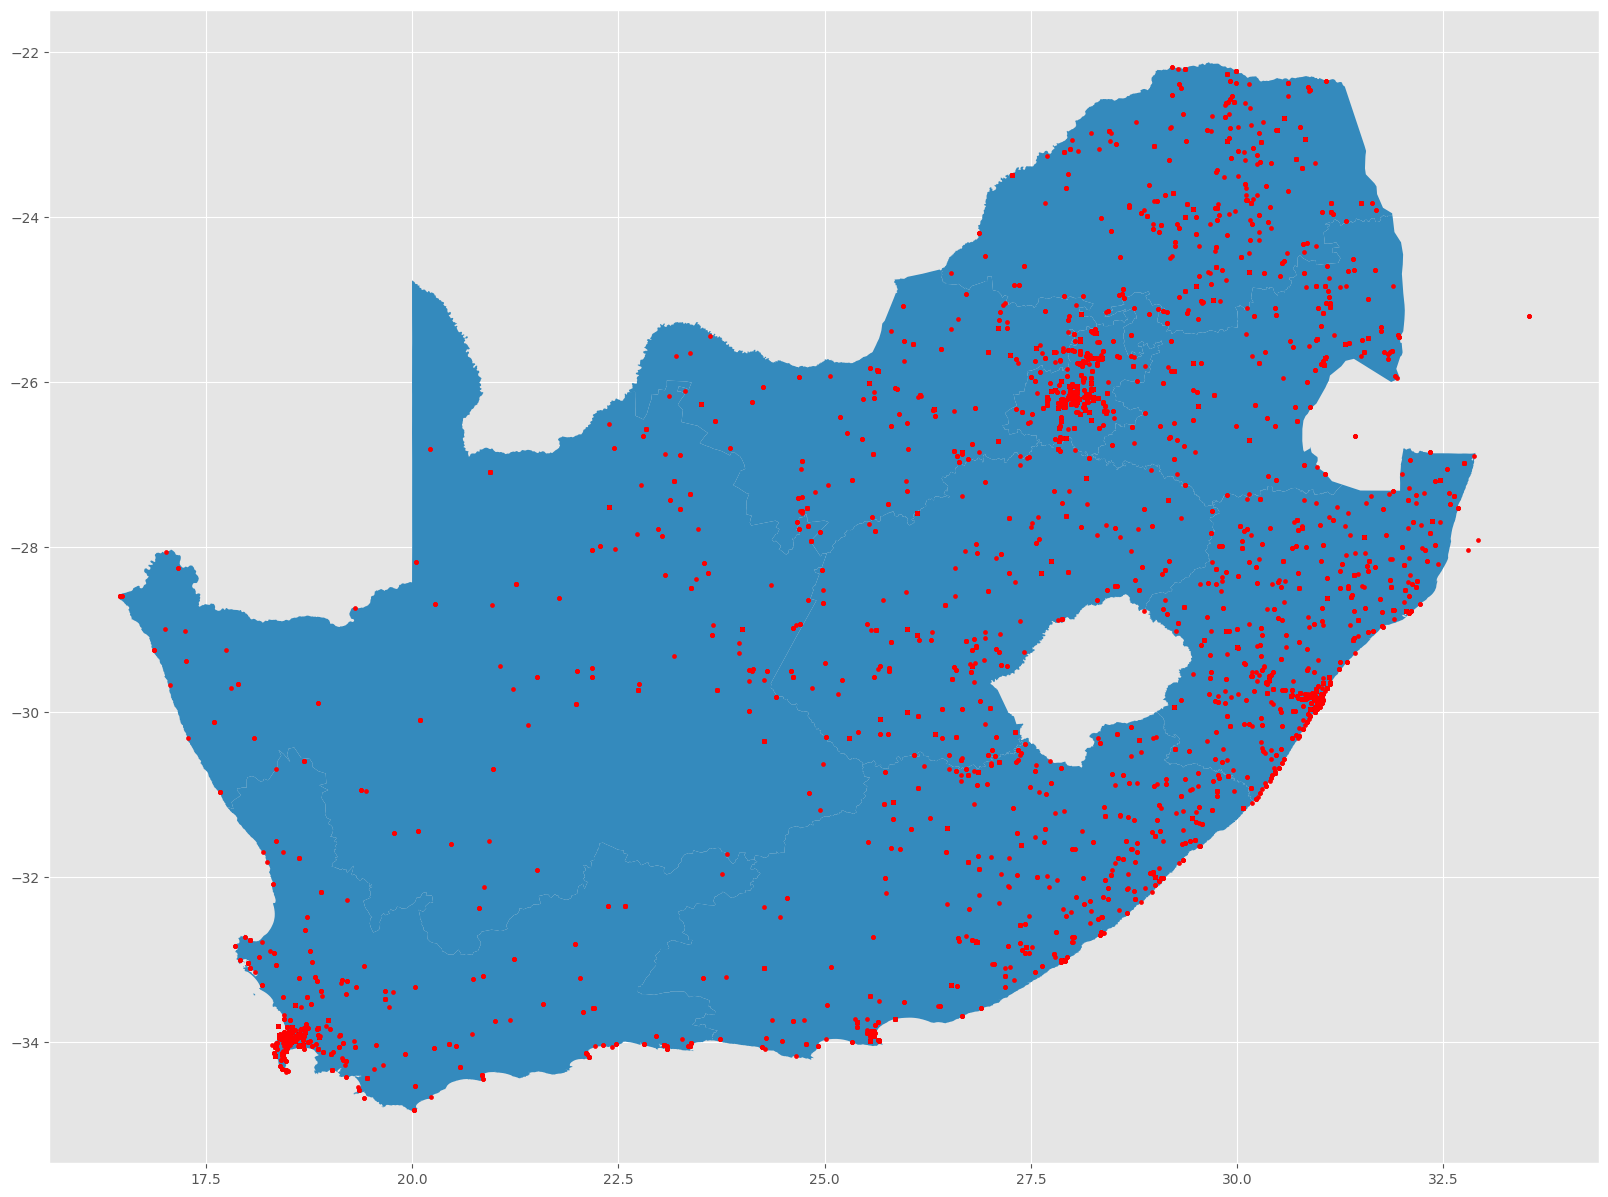

In [213]:
# Loading the South Africa Shapefile and Plotting GDELT Protests
SA = r"C:\Users\danie\OneDrive\Desktop\SA Shapefile\gadm41_ZAF_1.shp"
SAmap = gpd.read_file(SA)
gdfGDELT.plot(ax = SAmap.plot(figsize = (20, 20)), color = 'red', markersize = 8)

## Afrobarometer Data

In [214]:
# Read in the R7-9 Afrobarometer dataframes
dfR7 = pd.read_spss(r'C:\Users\danie\OneDrive\Desktop\R7.sav')
dfR8 = pd.read_spss(r'C:\Users\danie\OneDrive\Desktop\R8.sav')
dfR9 = pd.read_spss(r'C:\Users\danie\OneDrive\Desktop\R9.sav')

In [215]:
dfR7.head()

,RESPNO,URBRUR,EA_TYPE,REGION,DISTRICT,MUNICIPALITY,MAINPLACE,SUBPLACE,SALNUMBER,TOWNVILL,EANUMB_AB,EA_COMMENT,EA_GPS_LA,EA_GPS_LO,EA_GPS_OTHER,EA_SVC_A,EA_SVC_B,EA_SVC_C,EA_SVC_D,EA_FAC_A,EA_FAC_B,EA_FAC_C,EA_FAC_D,EA_FAC_E,EA_FAC_F,EA_FAC_G,EA_SEC_A,EA_SEC_B,EA_SEC_C,EA_SEC_D,EA_SEC_E,EA_ROAD_A,EA_ROAD_B,EA_ROAD_C,NOCALL_1,NOCALL_1OTHER,NOCALL_2,NOCALL_3,NOCALL_4,NOCALL_5,NOCALL_6,NOCALL_7,NOCALL_8,FIRSTINTRV,PREVINT,THISINT,ADULT_CT,CALLS,DATEINTR,STRTIME,Q1,Q2A,Q2AOTHER,Q2B,Q2BOTHER,Q3,Q4A,Q4B,Q5,Q6,Q7,Q8A,Q8B,Q8C,Q8D,Q8E,Q8F,Q9,Q10A,Q10B,Q11A,Q11B,Q12A,Q12B,Q12C,Q12D,Q12E,Q13,Q14,Q15,Q16,Q17,Q18A,Q18B,Q18C,Q18D,Q19A,Q19B,Q19C,Q19D,Q19E,Q20A,Q20B,Q21A,Q21B,Q22,Q23,Q24A,Q24B,Q25A,Q25B,Q25C,Q25D,Q25E,Q25F,Q26A,Q26B,Q26C,Q26D,Q26E,Q27A,Q27B,Q27C,Q27D_SAF,Q28,Q28A1_SAF,Q28A2_SAF,Q28A3_SAF,Q28B_SAF,Q29,Q30,Q31,Q32,Q33,Q34,Q35,Q36,Q37,Q38A,Q38B,Q38C,Q38D,Q38E,Q38F,Q38G,Q39A,Q39B,Q39C,Q40,Q41,Q42A,Q42B,Q42C,Q42D,Q42E,Q42F,Q42G_SAF,Q42H_SAF,Q43A,Q43B,Q43C,Q43C1_SAF,Q43D,Q43E,Q43F,Q43G,Q43H,Q43I,Q43I1_SAF,Q43I2_SAF,Q43J,Q43K,Q43L_SAF,Q43M_SAF,Q43N_SAF,Q43O_SAF,Q44A,Q44B,Q44C,Q44D,Q44E,Q44F,Q44G,Q44H,Q44I,Q44J,Q44K_SAF,Q44L_SAF,Q44M_SAF,Q45,Q46,Q47,Q48A,Q48B,Q48C,Q48D,Q48E,Q48F,Q49A,Q49B,Q49C,Q49D,Q49E,Q49F,Q49G,Q49H,Q49I,Q49J,Q49K,Q49L,Q49M,Q49N,Q49O,Q49P,Q49Q,Q49R,Q49S,Q49T,Q49U_SAF,Q49V_SAF,Q49W_SAF,Q49X_SAF,Q49Y_SAF,Q49Z_SAF,Q50,Q51,Q52,Q53A,Q53B,Q53C,Q54A,Q54B,Q55PT1,Q55PT1OTHER,Q55PT2,Q55PT2OTHER,Q55PT3,Q55PT3OTHER,Q56A,Q56B,Q56C,Q56D,Q56E,Q56F,Q56G,Q56H,Q56I,Q56J,Q56K,Q56L,Q56M,Q56N,Q56O,Q56P,Q56Q,Q56R,Q56S,Q56T_SAF,Q56U_SAF,Q57A,Q57B,Q57C,Q57D,Q57E,Q57F,Q57G,Q58A,Q58A1_SAF,Q58B,Q58B1_SAF,Q58C,Q58D,Q58E,Q59A,Q59B,Q59C,Q60A,Q60B,Q60C,Q60D,Q61A,Q61B,Q61C,Q62,Q63,Q64,Q65,Q66,Q67,Q68A,Q68B,Q69,Q70,Q70OTHER,Q71,Q72A,Q72B,Q73A,Q73B,Q74,Q75,Q76,Q77A,Q77B,Q77C,Q77D,Q78A,Q78B,Q79A_SAF,Q79B_SAF,Q79C_SAF,Q79D_SAF,Q79E1_SAF,Q79E2_SAF,Q79E3_SAF,Q80A_SAF,Q80B_SAF,Q80C_SAF,Q80D1_SAF,Q80D2_SAF,Q80D3_SAF,Q80D4_SAF,Q80D5_SAF,Q81A_SAF,Q81B_SAF,Q81C_SAF,Q82A_SAF,Q82B_SAF,Q82C_SAF,Q83A_SAF,Q83B_SAF,Q83C1_SAF,Q83C2_SAF,Q84,Q84OTHER,Q85A,Q85B,Q86A,Q86B,Q86C,Q86D,Q87A,Q87B,Q87C,Q87D,Q88A,Q88B,Q88BOTHER,Q89A,Q89B,Q89C,Q89D,Q89E,Q89F,Q90,Q91A,Q91B,Q92A,Q92B,Q93,Q94,Q95A,Q95B,Q95C,Q96A,Q96B,Q97,Q97A1_SAF,Q97A2_SAF,Q98,Q98OTHER,Q99,Q99OTHER,Q100,ENDTIME,LENGTH,Q101,Q102,Q102OTHER,Q103,Q103OTHER,Q104,Q105,Q106,Q107A,Q107B,Q107C,Q107D,Q107E,Q108,Q110A,Q110B,Q110C,Q110D,Q110E,Q110F,Q110G1,Q110G2,Q110G_NOCALL1,Q110G_NOCALL2,Q110G_NOCALL3,Q110G_NOCALL4,Q110G_NOCALL5,Q110G_NOCALL6,Q110G_NOCALL7,Q110G_NOCALL8,Q112,Q113,Q114,Q115,Q116,Q117,Q117OTHER,Q118,Q119_1,Q119_2,Q119_3,Q119_4,Q119_5,Q119_6,Q119_7,Q119_8,Q119_9,Q119OTHER,withinwt,AGE_COND,EDUC_COND,RELIG_COND,LivedPoverty,LivedPoverty_CAT,DemandDemo,SupplyDemo
0,SAF0009,Urban,FORMAL RESIDENTIAL,KwaZulu-Natal,ETHEKWINI,ETHEKWINI,PHOENIX,STANMORE,5992192.0,Phoenix,264.0,,-29.697385,31.019308,,Yes,Yes,Yes,No,No,Yes,No,No,Yes,No,Yes,Yes,No,No,No,No,Paved/ Tarred,Paved/ Tarred,Good,Interview was successful,,Interview was successful,Interview was successful,Interview was successful,Interview was successful,Interview was successful,Interview was successful,Interview was successful,"Yes, the first interview",Male,Female,4.0,1.0,2018-07-31,12:54:17,25.0,English\t,,English\t,,Going in the wrong direction,Neither good nor bad,Neither good nor bad,Same,Same,Better,Just once or twice,Never,Never,Never,Always,Several times a week,Not at all / Does not receive remittances,Several times,Several times,"Yes, three or more times","Yes, twice",A few times a month,Every day,Every day,Every day,Never,Occasionally,Not very free,Agree very strongly with 2,Agree very strongly with 2,Agree with 1,Not very likely,Not very likely,Don’t know/Haven’t heard,Don’t know/Haven’t heard,Somewhat more freedom,Somewhat more freedom,Much less freedom,Much less freedom,Don’t know,Not a Member,Not a Member,"No, but would do if had the chance","No, would never do this",You decided not to vote,Don’t know,No,No,Only once,Never,Only once,Never,Never,

In [216]:
dfR7.describe()

,SALNUMBER,EANUMB_AB,EA_GPS_LA,EA_GPS_LO,ADULT_CT,CALLS,Q113,withinwt,LivedPoverty
count,1.840000e+03,1840.000000,1840.000000,1840.000000,1840.00000,1840.000000,1840.000000,1840.000000,1818.000000
mean,5.925515e+06,231.075000,-28.470550,27.375770,2.13750,1.135326,30.686957,0.993842,0.971617
std,2.484760e+06,133.534007,3.176624,3.571876,1.64398,0.342165,7.086803,0.633031,0.887724
min,1.600057e+06,1.000000,-34.599768,17.592503,1.00000,1.000000,21.000000,0.050732,0.000000
25%,3.610108e+06,118.000000,-30.745342,26.265235,1.00000,1.000000,26.000000,0.584608,0.200000
50%,5.992870e+06,231.000000,-27.773575,28.088972,2.00000,1.000000,28.000000,0.923174,0.800000
75%,7.984069e+06,342.250000,-26.089282,30.007268,3.00000,1.000000,35.000000,1.234217,1.600000
max,9.870505e+06,510.000000,-22.803897,32.427590,15.00000,2.000000,48.000000,6.660400,4.000000


In [217]:
dfR8.describe()

,EANUMB,EANUMB_AB,EA_GPS_LA,EA_GPS_LO,LENGTH,Q113,withinwt_ea,withinwt_hh
count,1.600000e+03,1600.0000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000
mean,5.874818e+06,201.9175,-28.449156,26.970951,73.393750,32.014375,1.000000,1.000000
std,2.564906e+06,117.4684,3.235502,3.783159,23.849512,8.216910,0.606119,0.830417
min,1.610002e+06,1.0000,-34.304587,17.485492,-1.000000,21.000000,0.025156,0.006289
25%,3.607622e+06,100.7500,-30.630522,25.618957,58.000000,26.000000,0.666293,0.430556
50%,5.993478e+06,201.5000,-27.681108,28.045559,70.000000,30.000000,0.920147,0.800624
75%,7.984872e+06,302.2500,-26.074584,29.525353,85.000000,36.000000,1.229279,1.330603
max,9.870529e+06,510.0000,-22.766705,32.378865,313.000000,61.000000,7.410100,9.880134


In [218]:
dfR9.describe()

,EA_GPS_LA,EA_GPS_LO,EANUMB,EANUMB_AB,LENGTH,Q112,withinwt_ea,withinwt_hh
count,1580.000000,1580.000000,1.580000e+03,1580.000000,1580.000000,1580.000000,1580.000000,1580.000000
mean,-28.366453,27.064130,6.021926e+06,215.297468,74.820886,36.037975,1.000000,1.000000
std,3.191734,3.720529,2.579018e+06,130.229768,24.637772,7.705624,0.671819,0.877937
min,-34.564890,17.957026,1.610028e+06,1.000000,30.000000,21.000000,0.108554,0.043437
25%,-30.238607,25.631258,3.740015e+06,105.750000,60.000000,30.000000,0.635403,0.484488
50%,-27.446521,28.067334,5.994064e+06,210.500000,69.000000,34.000000,0.905686,0.796624
75%,-25.987432,29.565614,7.985214e+06,315.250000,83.000000,42.000000,1.170583,1.255470
max,-22.191139,32.368617,1.660000e+07,521.000000,295.000000,56.000000,7.137389,10.706084


### Afrobarometer Reduced & Renamed

In [219]:
# Create reduced dataframes with only the relevant questions for R7
dfR7_R = dfR7[['EA_GPS_LA',
               'EA_GPS_LO',
               'EA_FAC_B',
               'EA_FAC_C',
               'EA_FAC_D',
               'EA_ROAD_C',
               'Q3',
               'Q4A',
               'Q4B',
               'Q8A',
               'Q8B',
               'Q8C',
               'Q8D',
               'Q8E',
               'Q36',
               'Q49A',
               'Q49B',
               'Q49D',
               'Q49E',
               'Q49O',
               'Q49P',
               'Q97'
              ]].copy()

In [220]:
# Rename the 'EA_GPS_LO' column to 'AFRO_Long'
dfR7_R = dfR7_R.rename(columns={'EA_GPS_LO': 'AFRO_Long'})

# Rename the 'EA_GPS_LA' column to 'AFRO_Lat'
dfR7_R = dfR7_R.rename(columns={'EA_GPS_LA': 'AFRO_Lat'})

# Rename the 'EA_FAC_B' column to 'WalkSchool'
dfR7_R = dfR7_R.rename(columns={'EA_FAC_B': 'WalkSchool'})

# Rename the 'EA_FAC_C' column to 'WalkPolice'
dfR7_R = dfR7_R.rename(columns={'EA_FAC_C': 'WalkPolice'})

# Rename the 'EA_FAC_D' column to 'WalkClinic'
dfR7_R = dfR7_R.rename(columns={'EA_FAC_D': 'WalkClinic'})

# Rename the 'EA_ROAD_C' column to 'RoadCondition'
dfR7_R = dfR7_R.rename(columns={'EA_ROAD_C': 'RoadCondition'})

# Rename the 'Q3' column to 'CountryDirection'
dfR7_R = dfR7_R.rename(columns={'Q3': 'CountryDirection'})

# Rename the 'Q4A' column to 'CountryEconomicCondition'
dfR7_R = dfR7_R.rename(columns={'Q4A': 'CountryEconomicCondition'})

# Rename the 'Q4B' column to 'LivingCondition'
dfR7_R = dfR7_R.rename(columns={'Q4B': 'LivingCondition'})

# Rename the 'Q8A' column to 'NoFood'
dfR7_R = dfR7_R.rename(columns={'Q8A': 'NoFood'})

# Rename the 'Q8B' column to 'NoCleanWater'
dfR7_R = dfR7_R.rename(columns={'Q8B': 'NoCleanWater'})

# Rename the 'Q8C' column to 'NoMedicine'
dfR7_R = dfR7_R.rename(columns={'Q8C': 'NoMedicine'})

# Rename the 'Q8D' column to 'NoFuel'
dfR7_R = dfR7_R.rename(columns={'Q8D': 'NoFuel'})

# Rename the 'Q8E' column to 'NoIncome'
dfR7_R = dfR7_R.rename(columns={'Q8E': 'NoIncome'})

# Rename the 'Q36' column to 'Democracy'
dfR7_R = dfR7_R.rename(columns={'Q36': 'Democracy'})

# Rename the 'Q49A' column to 'SchoolContact'
dfR7_R = dfR7_R.rename(columns={'Q49A': 'SchoolContact'})

# Rename the 'Q49B' column to 'SchoolService'
dfR7_R = dfR7_R.rename(columns={'Q49B': 'SchoolService'})

# Rename the 'Q49D' column to 'ClinicContact'
dfR7_R = dfR7_R.rename(columns={'Q49D': 'ClinicContact'})

# Rename the 'Q49E' column to 'ClinicService'
dfR7_R = dfR7_R.rename(columns={'Q49E': 'ClinicService'})

# Rename the 'Q49O' column to 'PoliceContact'
dfR7_R = dfR7_R.rename(columns={'Q49O': 'PoliceContact'})

# Rename the 'Q49P' column to 'PoliceService'
dfR7_R = dfR7_R.rename(columns={'Q49P': 'PoliceService'})

# Rename the 'Q97' column to 'EducationLevel'
dfR7_R = dfR7_R.rename(columns={'Q97': 'EducationLevel'})

In [221]:
# Create reduced dataframes with only the relevant questions for R8
dfR8_R = dfR8[['EA_GPS_LA',
               'EA_GPS_LO',
               'EA_FAC_B',
               'EA_FAC_C',
               'EA_FAC_D',
               'EA_ROAD_C',
               'Q3',
               'Q4A',
               'Q4B',
               'Q7A',
               'Q7B',
               'Q7C',
               'Q7D',
               'Q7E',
               'Q37',
               'Q44A',
               'Q44B',
               'Q44D',
               'Q44E',
               'Q44J',
               'Q44K',
               'Q97'
              ]].copy()

In [222]:
# Rename the 'EA_GPS_LO' column to 'AFRO_Long'
dfR8_R = dfR8_R.rename(columns={'EA_GPS_LO': 'AFRO_Long'})

# Rename the 'EA_GPS_LA' column to 'AFRO_Lat'
dfR8_R = dfR8_R.rename(columns={'EA_GPS_LA': 'AFRO_Lat'})

# Rename the 'EA_FAC_B' column to 'WalkSchool'
dfR8_R = dfR8_R.rename(columns={'EA_FAC_B': 'WalkSchool'})

# Rename the 'EA_FAC_C' column to 'WalkPolice'
dfR8_R = dfR8_R.rename(columns={'EA_FAC_C': 'WalkPolice'})

# Rename the 'EA_FAC_D' column to 'WalkClinic'
dfR8_R = dfR8_R.rename(columns={'EA_FAC_D': 'WalkClinic'})

# Rename the 'EA_ROAD_C' column to 'RoadCondition'
dfR8_R = dfR8_R.rename(columns={'EA_ROAD_C': 'RoadCondition'})

# Rename the 'Q3' column to 'CountryDirection'
dfR8_R = dfR8_R.rename(columns={'Q3': 'CountryDirection'})

# Rename the 'Q4A' column to 'CountryEconomicCondition'
dfR8_R = dfR8_R.rename(columns={'Q4A': 'CountryEconomicCondition'})

# Rename the 'Q4B' column to 'LivingCondition'
dfR8_R = dfR8_R.rename(columns={'Q4B': 'LivingCondition'})

# Rename the 'Q8A' column to 'NoFood'
dfR8_R = dfR8_R.rename(columns={'Q7A': 'NoFood'})

# Rename the 'Q8B' column to 'NoCleanWater'
dfR8_R = dfR8_R.rename(columns={'Q7B': 'NoCleanWater'})

# Rename the 'Q8C' column to 'NoMedicine'
dfR8_R = dfR8_R.rename(columns={'Q7C': 'NoMedicine'})

# Rename the 'Q8D' column to 'NoFuel'
dfR8_R = dfR8_R.rename(columns={'Q7D': 'NoFuel'})

# Rename the 'Q8E' column to 'NoIncome'
dfR8_R = dfR8_R.rename(columns={'Q7E': 'NoIncome'})

# Rename the 'Q36' column to 'Democracy'
dfR8_R = dfR8_R.rename(columns={'Q37': 'Democracy'})

# Rename the 'Q49A' column to 'SchoolContact'
dfR8_R = dfR8_R.rename(columns={'Q44A': 'SchoolContact'})

# Rename the 'Q49B' column to 'SchoolService'
dfR8_R = dfR8_R.rename(columns={'Q44B': 'SchoolService'})

# Rename the 'Q49D' column to 'ClinicContact'
dfR8_R = dfR8_R.rename(columns={'Q44D': 'ClinicContact'})

# Rename the 'Q49E' column to 'ClinicService'
dfR8_R = dfR8_R.rename(columns={'Q44E': 'ClinicService'})

# Rename the 'Q49O' column to 'PoliceContact'
dfR8_R = dfR8_R.rename(columns={'Q44J': 'PoliceContact'})

# Rename the 'Q49P' column to 'PoliceService'
dfR8_R = dfR8_R.rename(columns={'Q44K': 'PoliceService'})

# Rename the 'Q97' column to 'EducationLevel'
dfR8_R = dfR8_R.rename(columns={'Q97': 'EducationLevel'})

In [223]:
# Create reduced dataframes with only the relevant questions for R9
dfR9_R = dfR9[['EA_GPS_LA',
               'EA_GPS_LO',
               'EA_FAC_B',
               'EA_FAC_C',
               'EA_FAC_D',
               'EA_ROAD_C',
               'Q3',
               'Q4A',
               'Q4B',
               'Q6A',
               'Q6B',
               'Q6C',
               'Q6D',
               'Q6E',
               'Q31',
               'Q40A',
               'Q40B',
               'Q41A',
               'Q41B',
               'Q43A',
               'Q43B',
               'Q94'
              ]].copy()

In [224]:
# Rename the 'EA_GPS_LO' column to 'AFRO_Long'
dfR9_R = dfR9_R.rename(columns={'EA_GPS_LO': 'AFRO_Long'})

# Rename the 'EA_GPS_LA' column to 'AFRO_Lat'
dfR9_R = dfR9_R.rename(columns={'EA_GPS_LA': 'AFRO_Lat'})

# Rename the 'EA_FAC_B' column to 'WalkSchool'
dfR9_R = dfR9_R.rename(columns={'EA_FAC_B': 'WalkSchool'})

# Rename the 'EA_FAC_C' column to 'WalkPolice'
dfR9_R = dfR9_R.rename(columns={'EA_FAC_C': 'WalkPolice'})

# Rename the 'EA_FAC_D' column to 'WalkClinic'
dfR9_R = dfR9_R.rename(columns={'EA_FAC_D': 'WalkClinic'})

# Rename the 'EA_ROAD_C' column to 'RoadCondition'
dfR9_R = dfR9_R.rename(columns={'EA_ROAD_C': 'RoadCondition'})

# Rename the 'Q3' column to 'CountryDirection'
dfR9_R = dfR9_R.rename(columns={'Q3': 'CountryDirection'})

# Rename the 'Q4A' column to 'CountryEconomicCondition'
dfR9_R = dfR9_R.rename(columns={'Q4A': 'CountryEconomicCondition'})

# Rename the 'Q4B' column to 'LivingCondition'
dfR9_R = dfR9_R.rename(columns={'Q4B': 'LivingCondition'})

# Rename the 'Q8A' column to 'NoFood'
dfR9_R = dfR9_R.rename(columns={'Q6A': 'NoFood'})

# Rename the 'Q8B' column to 'NoCleanWater'
dfR9_R = dfR9_R.rename(columns={'Q6B': 'NoCleanWater'})

# Rename the 'Q8C' column to 'NoMedicine'
dfR9_R = dfR9_R.rename(columns={'Q6C': 'NoMedicine'})

# Rename the 'Q8D' column to 'NoFuel'
dfR9_R = dfR9_R.rename(columns={'Q6D': 'NoFuel'})

# Rename the 'Q8E' column to 'NoIncome'
dfR9_R = dfR9_R.rename(columns={'Q6E': 'NoIncome'})

# Rename the 'Q36' column to 'Democracy'
dfR9_R = dfR9_R.rename(columns={'Q31': 'Democracy'})

# Rename the 'Q49A' column to 'SchoolContact'
dfR9_R = dfR9_R.rename(columns={'Q40A': 'SchoolContact'})

# Rename the 'Q49B' column to 'SchoolService'
dfR9_R = dfR9_R.rename(columns={'Q40B': 'SchoolService'})

# Rename the 'Q49D' column to 'ClinicContact'
dfR9_R = dfR9_R.rename(columns={'Q41A': 'ClinicContact'})

# Rename the 'Q49E' column to 'ClinicService'
dfR9_R = dfR9_R.rename(columns={'Q41B': 'ClinicService'})

# Rename the 'Q49O' column to 'PoliceContact'
dfR9_R = dfR9_R.rename(columns={'Q43A': 'PoliceContact'})

# Rename the 'Q49P' column to 'PoliceService'
dfR9_R = dfR9_R.rename(columns={'Q43B': 'PoliceService'})

# Rename the 'Q97' column to 'EducationLevel'
dfR9_R = dfR9_R.rename(columns={'Q94': 'EducationLevel'})

In [225]:
dfR7_R["Year"] = 2018
dfR8_R["Year"] = 2021
dfR9_R["Year"] = 2022

### Afrobarometer Merged, Haversine, & Mapping

In [226]:
afro_merged_df = pd.merge(dfR7_R, dfR8_R, how='outer')  # Merge dfR7_R and dfR8_R
afro_merged_df = pd.merge(afro_merged_df, dfR9_R, how='outer')  # Merge afro_merged_df with dfR9_R

In [227]:
# Get the Haversine distance for Afrobarometer data
afro_merged_df['AFRO_Haversine'] = [single_pt_haversine(AFRO_Lat, AFRO_Long) 
                         for AFRO_Lat, AFRO_Long in zip(afro_merged_df.AFRO_Lat, afro_merged_df.AFRO_Long)]

In [228]:
# Drop duplicates from AFRO_Haversine
#afro_merged_df = afro_merged_df.drop_duplicates(subset=["AFRO_Haversine"], keep='first')

In [229]:
afro_merged_df.head()

,AFRO_Lat,AFRO_Long,WalkSchool,WalkPolice,WalkClinic,RoadCondition,CountryDirection,CountryEconomicCondition,LivingCondition,NoFood,NoCleanWater,NoMedicine,NoFuel,NoIncome,Democracy,SchoolContact,SchoolService,ClinicContact,ClinicService,PoliceContact,PoliceService,EducationLevel,Year,AFRO_Haversine
0,-29.697385,31.019308,Yes,No,No,Good,Going in the wrong direction,Neither good nor bad,Neither good nor bad,Just once or twice,Never,Never,Never,Always,Not very satisfied,Yes,Difficult,Yes,Very Difficult,Yes,Very Difficult,Secondary school / high school completed,2018,4657.926765
1,-29.998082,30.898993,Yes,No,Yes,Fair,Going in the right direction,Fairly Bad,Neither good nor bad,Never,Never,Never,Never,Never,Not at all satisfied,No,No contact,Yes,Easy,Yes,Very easy,Secondary school / high school completed,2018,4670.345361
2,-29.625710,31.054165,No,No,No,Fair,Going in the wrong direction,Very Bad,Very Bad,Never,Never,Never,Many times,Always,Not very satisfied,No,No contact,Yes,Difficult,Yes,Difficult,Some secondary school / high school,2018,4655.465612
3,-29.639950,31.041608,Yes,No,No,Very good,Going in the wrong direction,Very Bad,Neither good nor bad,Several times,Several times,Never,Several times,Never,Not at all satisfied,Yes,Difficult,Yes,Very Difficult,Yes,Very Difficult,Post-graduate,2018,4655.532751
4,-29.639950,31.041608,Yes,No,No,Very good,Going in the wrong direction,Very Bad,Neither good nor bad,Never,Never,Don't know,Never,Never,Not very satisfied,No,No contact,Yes,Difficult,No,No contact,Secondary school / high school completed,2018,4655.532751


In [230]:
afro_merged_df.describe()

,AFRO_Lat,AFRO_Long,Year,AFRO_Haversine
count,5020.000000,5020.000000,5020.000000,5020.000000
mean,-28.430968,27.148658,2020.215139,4311.229166
std,3.199916,3.690606,1.731513,214.310353
min,-34.599768,17.485492,2018.000000,3665.438118
25%,-30.567991,26.064922,2018.000000,4171.282112
50%,-27.698600,28.064918,2021.000000,4235.567324
75%,-26.040437,29.733795,2022.000000,4518.633355
max,-22.191139,32.427590,2022.000000,4694.288143


In [231]:
# Coverting afro_merged_df to geopandas dataframe
geometry = [Point(xy) for xy in zip(afro_merged_df['AFRO_Long'], afro_merged_df['AFRO_Lat'])]
gdfAFRO = GeoDataFrame(afro_merged_df, geometry = geometry)

<Axes: >

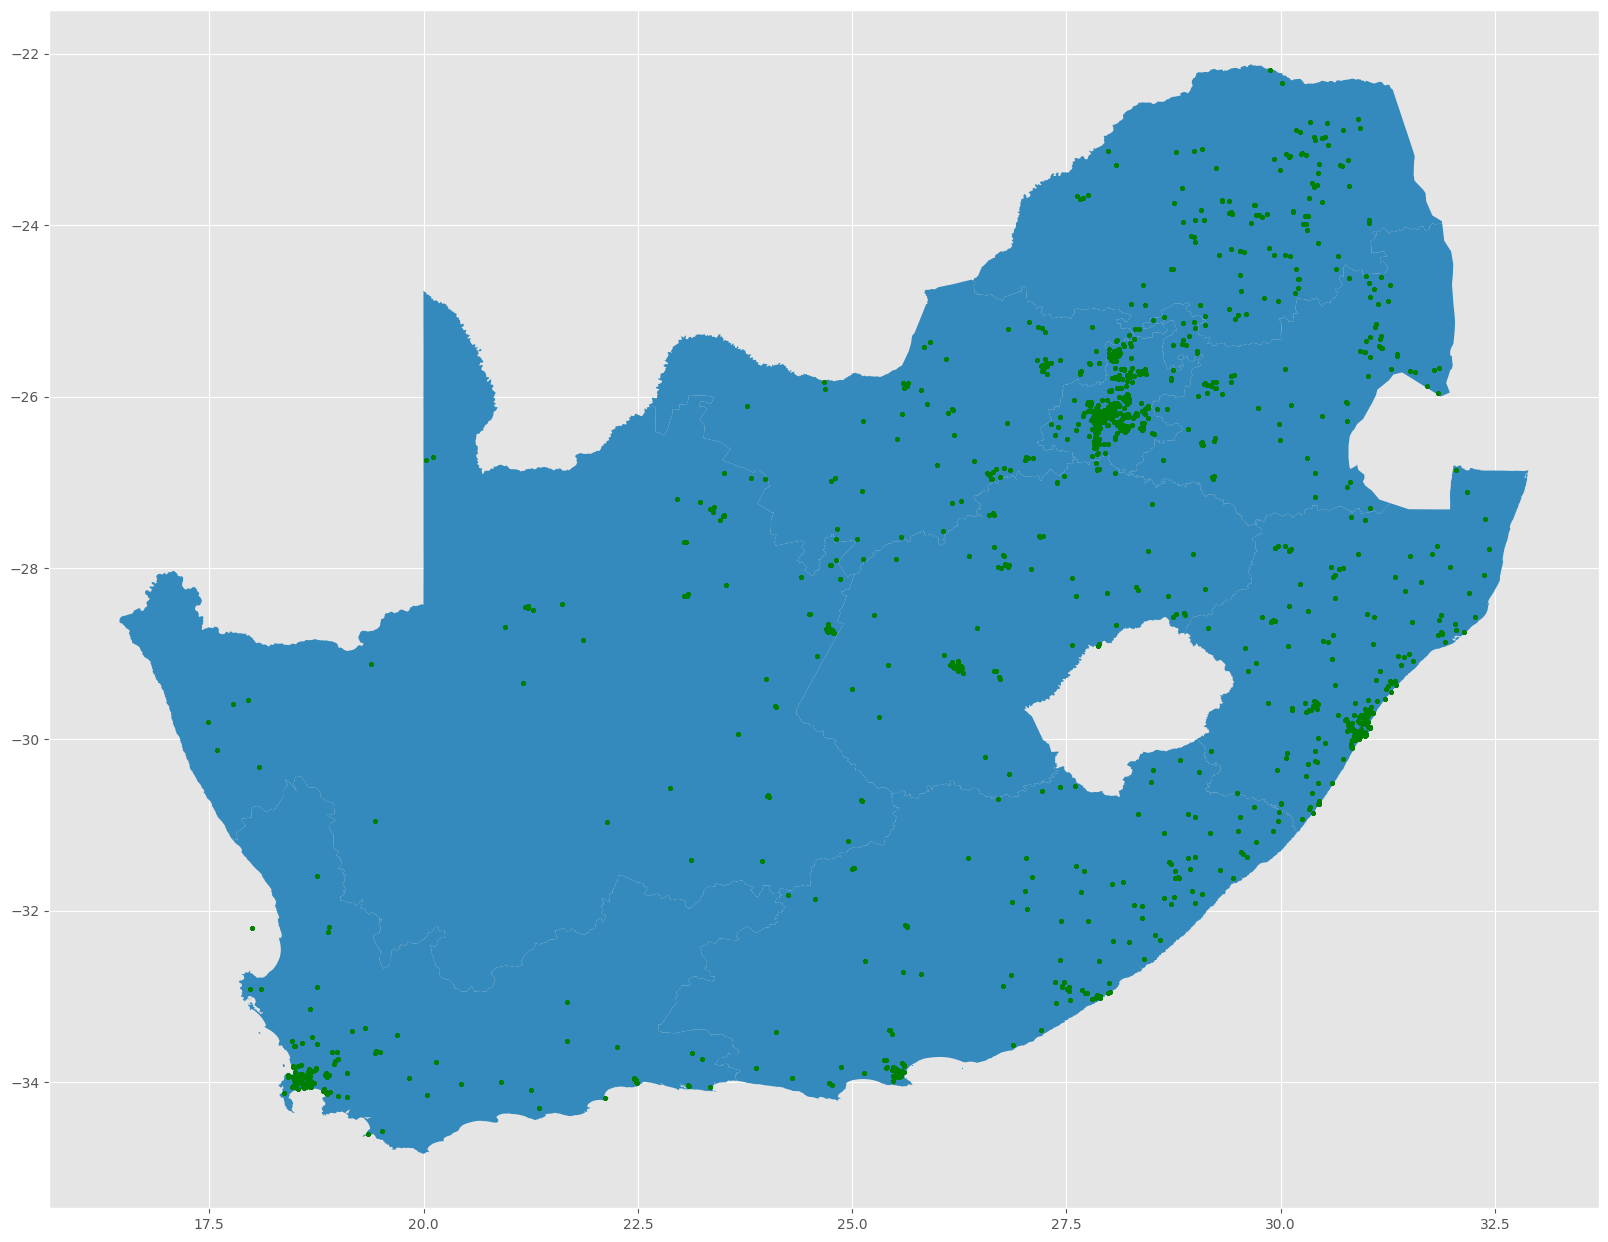

In [232]:
# Loading the South Africa Shapefile and Plotting Afro Response Area
SA = r"C:\Users\danie\OneDrive\Desktop\SA Shapefile\gadm41_ZAF_1.shp"
SAmap = gpd.read_file(SA)
gdfAFRO.plot(ax = SAmap.plot(figsize = (20, 20)), color = 'green', markersize = 8)

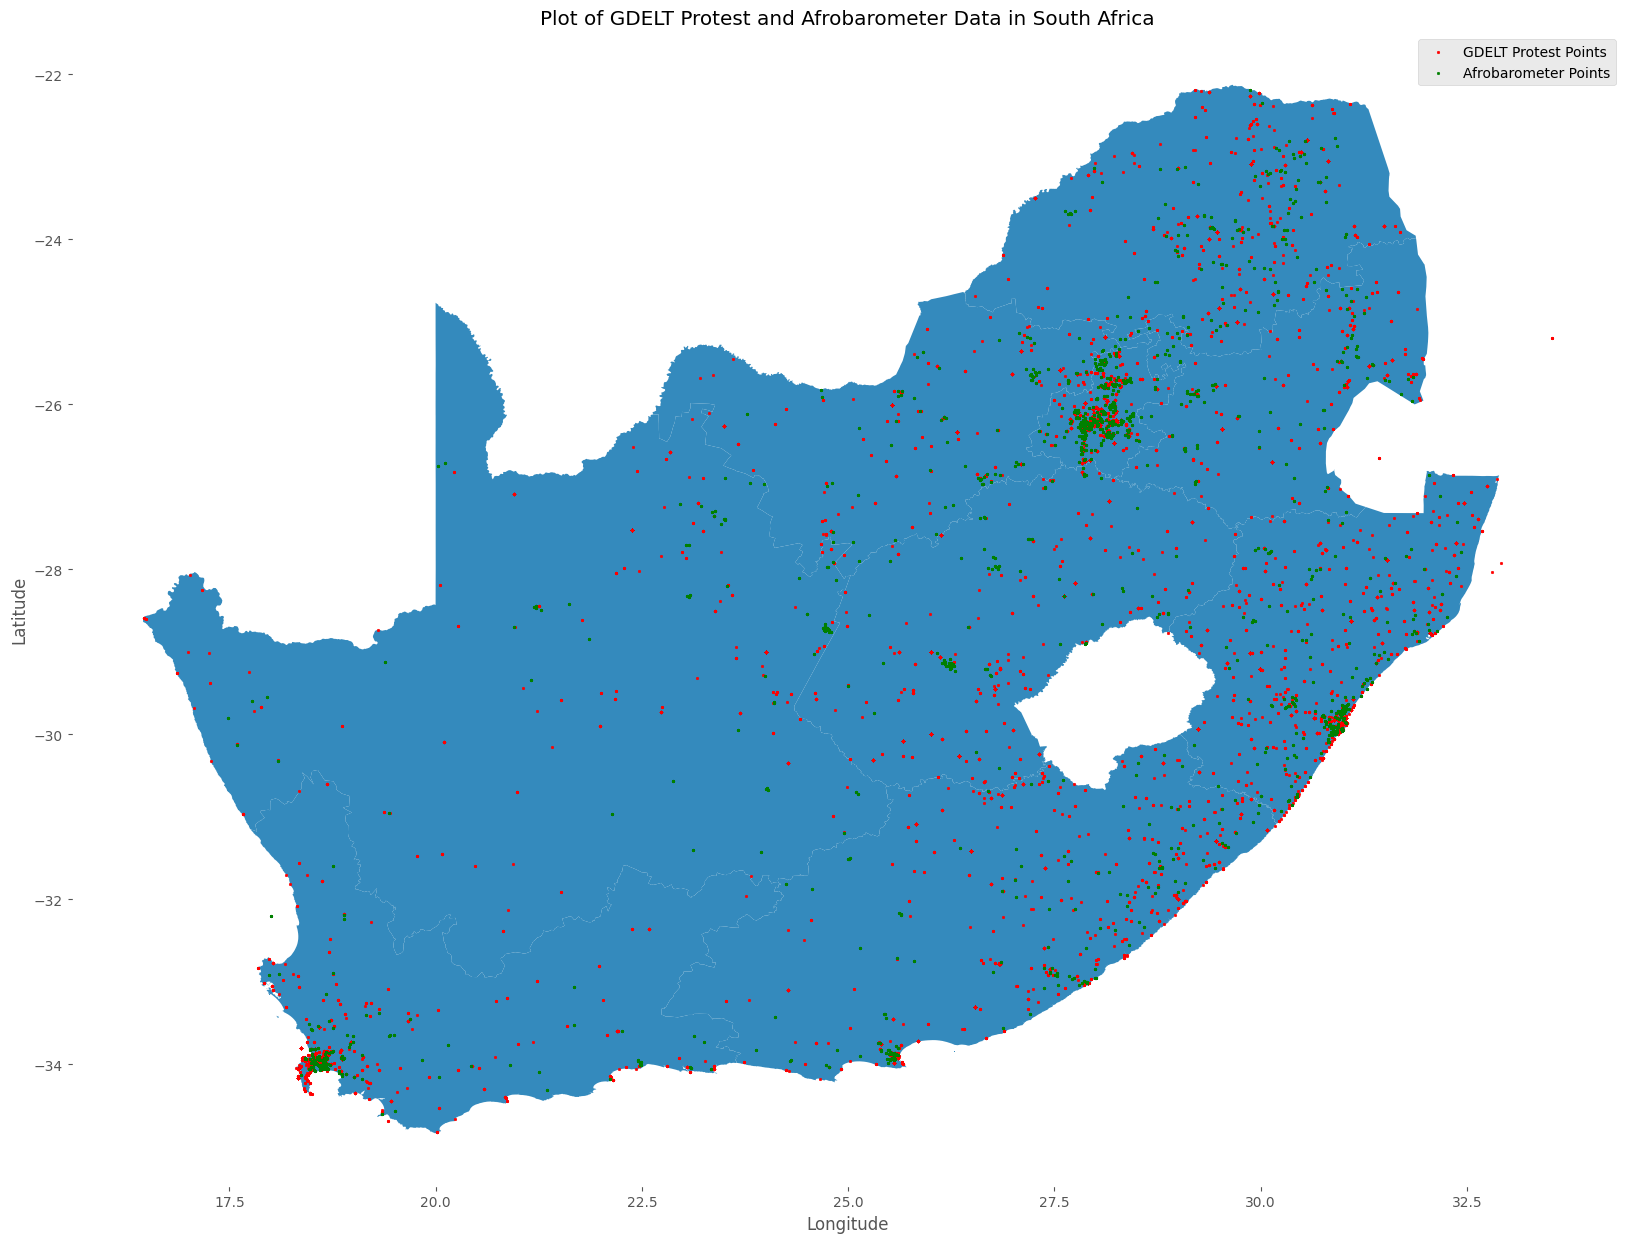

In [233]:
fig, ax = plt.subplots(figsize = (20, 20))
SAmap = gpd.read_file(SA)
base = SAmap.plot(ax = ax)
GDELTmap = gdfGDELT.plot(ax = ax, color = 'red', markersize = 3)
AFROmap = gdfAFRO.plot(ax = ax, color = 'green', markersize = 3)
plt.title('Plot of GDELT Protest and Afrobarometer Data in South Africa')
plt.ylabel('Latitude')
plt.xlabel('Longitude')
location = 0 # For the best location
legend_drawn_flag = True
plt.legend(["GDELT Protest Points", "Afrobarometer Points"], loc=0, frameon=legend_drawn_flag)
ax.set_facecolor('white')
plt.show()

### Afrobarometer Binary & Ordinal Encoding

#### Binary Dummy

In [234]:
# Create Binary Dummy Variables
afro_merged_df['WalkSchool'] = afro_merged_df['WalkSchool'].replace({'No': 1, 'Yes': 0, "Can't determine" : 0, "Don't Know" : 0, 'Refused to Answer' : 0, 'Do not know' : 0})
afro_merged_df['WalkPolice'] = afro_merged_df['WalkPolice'].replace({'No': 1, 'Yes': 0, "Can't determine" : 0, "Don't Know" : 0, 'Refused to Answer' : 0, 'Do not know' : 0})
afro_merged_df['WalkClinic'] = afro_merged_df['WalkClinic'].replace({'No': 1, 'Yes': 0, "Can't determine" : 0, "Don't Know" : 0, 'Refused to Answer' : 0, 'Do not know' : 0})
afro_merged_df['SchoolContact'] = afro_merged_df['SchoolContact'].replace({'No': 1, 'Yes': 0, "Can't determine" : 0, "Don't Know" : 0, "Don't know" : 0, 'Refused to Answer' : 0, 'Do not know' : 0})
afro_merged_df['ClinicContact'] = afro_merged_df['ClinicContact'].replace({'No': 1, 'Yes': 0, "Can't determine" : 0, "Don't Know" : 0, "Don't know" : 0, 'Refused to Answer' : 0, 'Do not know' : 0})
afro_merged_df['PoliceContact'] = afro_merged_df['PoliceContact'].replace({'No': 1, 'Yes': 0, "Can't determine" : 0, "Don't Know" : 0, "Don't know" : 0, 'Refused to Answer' : 0, 'Do not know' : 0})

#### Nominal OneHot Encoding

In [235]:
# Define a mapping dictionary for replacement of RoadCondition
replacement_dict = {
    'Impassable': 6,
    'Very poor': 5,
    'Poor': 4,
    'Fair': 3,
    'Good': 2,
    'Very good': 1,
    'Refused': 0,
    'Do not know': 0,
    "Don't Know": 0,
    "Don't know": 0
}

# Replace values in the 'RoadCondition' column with numerical values
afro_merged_df['RoadCondition'] = afro_merged_df['RoadCondition'].replace(replacement_dict)

In [236]:
# Define a mapping dictionary for replacement of CountryDirection
replacement_dict = {
    'Going in the wrong direction': 1,
    'Going in the right direction': 0,
    'Refused': 0,
    'Do not know': 0,
    "Don't Know": 0,
    "Don't know": 0
}

# Replace values in the 'CountryDirection' column with numerical values
afro_merged_df['CountryDirection'] = afro_merged_df['CountryDirection'].replace(replacement_dict)

In [237]:
# Define a mapping dictionary for replacement of CountryEconomicCondition
replacement_dict = {
    'Very Bad': 5,
    'Very bad': 5,
    'Fairly Bad': 4,
    'Fairly bad': 4,
    'Neither good nor bad': 3,
    'Fairly Good': 2,
    'Fairly good': 2,
    'Very good': 1,
    'Refused': 0,
    "Don't Know": 0,
    'Do not know': 0,
    "Don't know": 0
}

# Replace values in the 'CountryEconomicCondition' column with numerical values
afro_merged_df['CountryEconomicCondition'] = afro_merged_df['CountryEconomicCondition'].replace(replacement_dict)

In [238]:
# Define a mapping dictionary for replacement of LivingCondition
replacement_dict = {
    'Very Bad': 5,
    'Very bad': 5,
    'Fairly Bad': 4,
    'Fairly bad': 4,
    'Neither good nor bad': 3,
    'Fairly Good': 2,
    'Fairly good': 2,
    'Very good': 1,
    'Refused': 0,
    'Do not know': 0,
    "Don't Know": 0,
    "Don't know": 0
}

# Replace values in the 'LivingCondition' column with numerical values
afro_merged_df['LivingCondition'] = afro_merged_df['LivingCondition'].replace(replacement_dict)

In [239]:
# Define a mapping dictionary for replacement of NoFood
replacement_dict = {
    'Never': 0,
    'Just once or twice': 1,
    'Several times': 2,
    'Many times': 3,
    'Always': 4,
    'Refused': 0,
    'Do not know': 0,
    "Don't Know": 0,
    "Don't know": 0
}

# Replace values in the 'NoFood' column with numerical values
afro_merged_df['NoFood'] = afro_merged_df['NoFood'].replace(replacement_dict)

In [240]:
# Define a mapping dictionary for replacement of NoCleanWater
replacement_dict = {
    'Never': 0,
    'Just once or twice': 1,
    'Several times': 2,
    'Many times': 3,
    'Always': 4,
    'Refused': 0,
    'Do not know': 0,
    "Don't Know": 0,
    "Don't know": 0
}

# Replace values in the 'NoCleanWater' column with numerical values
afro_merged_df['NoCleanWater'] = afro_merged_df['NoCleanWater'].replace(replacement_dict)

In [241]:
# Define a mapping dictionary for replacement of NoMedicine
replacement_dict = {
    'Never': 0,
    'Just once or twice': 1,
    'Several times': 2,
    'Many times': 3,
    'Always': 4,
    'Refused': 0,
    'Do not know': 0,
    "Don't Know": 0,
    "Don't know": 0
}

# Replace values in the 'NoMedicine' column with numerical values
afro_merged_df['NoMedicine'] = afro_merged_df['NoMedicine'].replace(replacement_dict)

In [242]:
# Define a mapping dictionary for replacement of NoFuel
replacement_dict = {
    'Never': 0,
    'Just once or twice': 1,
    'Several times': 2,
    'Many times': 3,
    'Always': 4,
    'Refused': 0,
    'Do not know': 0,
    "Don't Know": 0,
    "Don't know": 0
}

# Replace values in the 'NoFuel' column with numerical values
afro_merged_df['NoFuel'] = afro_merged_df['NoFuel'].replace(replacement_dict)

In [243]:
# Define a mapping dictionary for replacement of NoIncome
replacement_dict = {
    'Never': 0,
    'Just once or twice': 1,
    'Several times': 2,
    'Many times': 3,
    'Always': 4,
    'Refused': 0,
    'Do not know': 0,
    "Don't Know": 0,
    "Don't know": 0
}

# Replace values in the 'NoIncome' column with numerical values
afro_merged_df['NoIncome'] = afro_merged_df['NoIncome'].replace(replacement_dict)

In [244]:
# Define a mapping dictionary for replacement of Democracy
replacement_dict = {
    'The country is not a democracy': 4,
    'Not at all satisfied': 3,
    'Not very satisfied': 2,
    'Fairly satisfied': 1,
    'Very satisfied': 0,
    'Refused': 0,
    'Do not know': 0,
    "Don't Know": 0,
    "Don't know": 0
}

# Replace values in the 'Democracy' column with numerical values
afro_merged_df['Democracy'] = afro_merged_df['Democracy'].replace(replacement_dict)

In [245]:
# Define a mapping dictionary for replacement of SchoolService
replacement_dict = {
    'No contact': 0,
    'Very easy': 1,
    'Easy': 2,
    'Difficult': 3,
    'Very Difficult': 4,
    'Refused': 0,
    'Not Applicable': 0,
    'Do not know': 0,
    "Don't Know": 0,
    "Don't know": 0
}

# Replace values in the 'SchoolService' column with numerical values
afro_merged_df['SchoolService'] = afro_merged_df['SchoolService'].replace(replacement_dict)

In [246]:
# Define a mapping dictionary for replacement of ClinicService
replacement_dict = {
    'No contact': 0,
    'Very easy': 1,
    'Easy': 2,
    'Difficult': 3,
    'Very Difficult': 4,
    'Not Applicable': 0,
    'Do not know': 0,
    "Don't Know": 0,
    "Don't know": 0
}

# Replace values in the 'ClinicService' column with numerical values
afro_merged_df['ClinicService'] = afro_merged_df['ClinicService'].replace(replacement_dict)

In [247]:
# Define a mapping dictionary for replacement of PoliceService
replacement_dict = {
    'No contact': 0,
    'Very easy': 1,
    'Easy': 2,
    'Difficult': 3,
    'Very Difficult': 4,
    'Not Applicable': 0,
    'Do not know': 0,
    "Don't Know": 0,
    "Don't know": 0
}

# Replace values in the 'PoliceService' column with numerical values
afro_merged_df['PoliceService'] = afro_merged_df['PoliceService'].replace(replacement_dict)

In [248]:
# Define a mapping dictionary for replacement of EducationLevel
replacement_dict = {
    'No formal schooling': 10,
    'Informal schooling only': 9,
    'Informal schooling only (including Koranic schooling)': 9,
    'Some primary schooling': 8,
    'Primary school completed': 7,
    'Some secondary school / high school': 6,
    'Intermediate school or Some secondary school / high school': 6,
    'Secondary school / high school completed': 5,
    'Post-secondary qualifications, other than university': 4,
    'Post-secondary qualifications, other than university e.g. a diploma or degree from a polytechnic or college': 4,
    'Some university': 3,
    'University completed': 2,
    'Post-graduate': 1,
    'Refused': 0,
    'Do not know': 0,
    "Don't Know": 0,
    "Don't know": 0,
    "Don’t know": 0
}

# Replace values in the 'EducationLevel' column with numerical values
afro_merged_df['EducationLevel'] = afro_merged_df['EducationLevel'].replace(replacement_dict)

### Composite Index Construction

In [249]:
# Convert data types to int64
afro_merged_df['WalkClinic'] = afro_merged_df["WalkClinic"].cat.codes.astype('int64')
afro_merged_df['WalkPolice'] = afro_merged_df["WalkPolice"].cat.codes.astype('int64')
afro_merged_df['RoadCondition'] = afro_merged_df["RoadCondition"].cat.codes.astype('int64')
afro_merged_df['CountryDirection'] = afro_merged_df["CountryDirection"].cat.codes.astype('int64')
afro_merged_df['Democracy'] = afro_merged_df["Democracy"].cat.codes.astype('int64')

In [250]:
afro_merged_df.dtypes

AFRO_Lat                    float64
AFRO_Long                   float64
WalkSchool                    int64
WalkPolice                    int64
WalkClinic                    int64
RoadCondition                 int64
CountryDirection              int64
CountryEconomicCondition      int64
LivingCondition               int64
NoFood                        int64
NoCleanWater                  int64
NoMedicine                    int64
NoFuel                        int64
NoIncome                      int64
Democracy                     int64
SchoolContact                 int64
SchoolService                 int64
ClinicContact                 int64
ClinicService                 int64
PoliceContact                 int64
PoliceService                 int64
EducationLevel                int64
Year                          int64
AFRO_Haversine              float64
dtype: object

#### Income Level Proxy Index (Poverty Measure)

In [251]:
# WalkSchool WalkPolice WalkClinic LivingCondition NoFood NoCleanWater NoMedicine NoFuel NoIncome

afro_merged_df["Income Level Proxy Index"] = afro_merged_df["WalkSchool"] + afro_merged_df["WalkPolice"] + afro_merged_df["WalkClinic"] + afro_merged_df["LivingCondition"] + afro_merged_df["NoFood"] + afro_merged_df["NoCleanWater"] + afro_merged_df["NoMedicine"] + afro_merged_df["NoFuel"] + afro_merged_df["NoIncome"]

#### Service Delivery Proxy Index

In [252]:
# RoadCondition SchoolService ClinicService PoliceService

afro_merged_df["Service Delivery Proxy Index"] = afro_merged_df["RoadCondition"] + afro_merged_df["SchoolService"] + afro_merged_df["ClinicService"] + afro_merged_df["PoliceService"]

#### Satisfaction Proxy Index (Political Measure)

In [253]:
# CountryDirection CountryEconomicCondition Democracy

afro_merged_df["Satisfaction Proxy Index"] = afro_merged_df["CountryDirection"] + afro_merged_df["CountryEconomicCondition"] + afro_merged_df["Democracy"]

### GDELT & Afrobarometer Haversine Compared

##### Calculating all the protests within a 25km radius for AFRO data points

In [254]:
year_cache = {}
points_cache = {}
distances = []
for i, row1 in afro_merged_df.iterrows():
    filtered_df = year_cache.get(row1["Year"])
    gdelt_points = points_cache.get(row1["Year"])
    
    # Caching filtered data set to improve run time
    if filtered_df is None:    
        filtered_df = df[(df['Year'] >= row1["Year"]) & (df['Year'] <= row1["Year"] + 1)]
        year_cache[row1["Year"]] = filtered_df
    if gdelt_points is None:
        gdelt_points = list(zip(filtered_df["GDELT_Lat"].tolist(), filtered_df["GDELT_Long"].tolist()))
        points_cache[row1["Year"]] = gdelt_points

    afro_points = [(row1["AFRO_Lat"], row1["AFRO_Long"])] * filtered_df.shape[0]
    dists = haversine_vector(afro_points, gdelt_points)
    distances.append(len([x for x in dists if x <= 25]))


afro_merged_df["Number of Protest in 25km radius"] = distances

afro_merged_df.head()

,AFRO_Lat,AFRO_Long,WalkSchool,WalkPolice,WalkClinic,RoadCondition,CountryDirection,CountryEconomicCondition,LivingCondition,NoFood,NoCleanWater,NoMedicine,NoFuel,NoIncome,Democracy,SchoolContact,SchoolService,ClinicContact,ClinicService,PoliceContact,PoliceService,EducationLevel,Year,AFRO_Haversine,Income Level Proxy Index,Service Delivery Proxy Index,Satisfaction Proxy Index,Number of Protest in 25km radius
0,-29.697385,31.019308,0,1,1,1,1,3,3,1,0,0,0,4,3,0,3,0,4,0,4,5,2018,4657.926765,10,12,7,1507
1,-29.998082,30.898993,0,1,0,0,0,4,3,0,0,0,0,0,2,1,0,0,2,0,1,5,2018,4670.345361,4,3,6,1442
2,-29.625710,31.054165,1,1,1,0,1,5,5,0,0,0,3,4,3,1,0,0,3,0,3,6,2018,4655.465612,15,6,9,179
3,-29.639950,31.041608,0,1,1,4,1,5,3,2,2,0,2,0,2,0,3,0,4,0,4,1,2018,4655.532751,11,15,8,1453
4,-29.639950,31.041608,0,1,1,4,1,5,3,0,0,0,0,0,3,1,0,0,3,1,0,5,2018,4655.532751,5,7,9,1453


##### Calculating all the at risk points within a 25km radius for GDELT data points

In [255]:
year_cache = {}
points_cache = {}
distances = []
for i, row1 in df.iterrows():
    filtered_df = year_cache.get(row1["Year"])
    afro_points = points_cache.get(row1["Year"])
    # Caching filtered data set to improve run time
    if filtered_df is None:    
        filtered_df = afro_merged_df[(afro_merged_df['Year'] >= row1["Year"]- 1) & (afro_merged_df['Year'] <= row1["Year"] + 2)]
        year_cache[row1["Year"]] = filtered_df
    if afro_points is None:
        afro_points = list(zip(filtered_df["AFRO_Lat"].tolist(), filtered_df["AFRO_Long"].tolist()))
        points_cache[row1["Year"]] = afro_points

        

    gdelt_points = [(row1["GDELT_Lat"], row1["GDELT_Long"])] * filtered_df.shape[0]  
    dists = haversine_vector(gdelt_points, afro_points)
    distances.append(len([x for x in dists if x <= 25]))


df["Number of at risk points in 25km radius"] = distances

df.head()

,GlobalEventID,Year,GDELT_Long,GDELT_Lat,GDELT_Haversine,Number of at risk points in 25km radius
0,885731620,2019,19.6663,-33.4771,4251.817764,4
1,885731629,2019,19.6663,-33.4771,4251.817764,4
2,885775267,2019,27.8672,-26.2234,4173.016154,305
3,776780306,2018,29.9924,-22.3708,4090.075635,0
4,776755077,2018,18.4955,-34.0289,4246.697089,113


##### Location Fixed Effect

In [256]:
# https://towardsdatascience.com/how-to-easily-join-data-by-location-in-python-spatial-join-197490ff3544
# https://gadm.org/download_country.html

In [257]:
# Coverting afro_merged_df to geopandas dataframe
geometry = [Point(xy) for xy in zip(afro_merged_df['AFRO_Long'], afro_merged_df['AFRO_Lat'])]
gdf_Afro = GeoDataFrame(afro_merged_df, geometry = geometry)

# Loading the South Africa Shapefile and Plotting Afro Response Area
SA = r"C:\Users\danie\OneDrive\Desktop\SA Shapefile\gadm41_ZAF_1.shp"
SAmap = gpd.read_file(SA)
SAmap.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,ZAF.1_1,ZAF,South Africa,Eastern Cape,Oos-Kaap,NA,Provinsie,Province,EC,ZA.EC,ZA-EC,"MULTIPOLYGON (((24.90375 -34.08597, 24.90375 -..."
1,ZAF.2_1,ZAF,South Africa,Free State,Orange Free State|Vrystaat,NA,Provinsie,Province,FS,ZA.FS,ZA-FS,"POLYGON ((26.48242 -30.62890, 26.48203 -30.628..."
2,ZAF.3_1,ZAF,South Africa,Gauteng,Pretoria/Witwatersrand/Vaal,NA,Provinsie,Province,GT,ZA.GT,ZA-GP,"POLYGON ((27.83885 -26.74905, 27.83810 -26.749..."
3,ZAF.4_1,ZAF,South Africa,KwaZulu-Natal,Natal and Zululand,NA,Provinsie,Province,KZN,ZA.NL,NA,"MULTIPOLYGON (((30.28403 -30.97125, 30.28375 -..."
4,ZAF.5_1,ZAF,South Africa,Limpopo,Noordelike Provinsie|Northern Tr,NA,Provinsie,Province,LIM,ZA.NP,ZA-LP,"POLYGON ((29.79346 -25.36206, 29.79319 -25.362..."


In [258]:
gdf_Afro.head()

,AFRO_Lat,AFRO_Long,WalkSchool,WalkPolice,WalkClinic,RoadCondition,CountryDirection,CountryEconomicCondition,LivingCondition,NoFood,NoCleanWater,NoMedicine,NoFuel,NoIncome,Democracy,SchoolContact,SchoolService,ClinicContact,ClinicService,PoliceContact,PoliceService,EducationLevel,Year,AFRO_Haversine,Income Level Proxy Index,Service Delivery Proxy Index,Satisfaction Proxy Index,Number of Protest in 25km radius,geometry
0,-29.697385,31.019308,0,1,1,1,1,3,3,1,0,0,0,4,3,0,3,0,4,0,4,5,2018,4657.926765,10,12,7,1507,POINT (31.01931 -29.69739)
1,-29.998082,30.898993,0,1,0,0,0,4,3,0,0,0,0,0,2,1,0,0,2,0,1,5,2018,4670.345361,4,3,6,1442,POINT (30.89899 -29.99808)
2,-29.625710,31.054165,1,1,1,0,1,5,5,0,0,0,3,4,3,1,0,0,3,0,3,6,2018,4655.465612,15,6,9,179,POINT (31.05417 -29.62571)
3,-29.639950,31.041608,0,1,1,4,1,5,3,2,2,0,2,0,2,0,3,0,4,0,4,1,2018,4655.532751,11,15,8,1453,POINT (31.04161 -29.63995)
4,-29.639950,31.041608,0,1,1,4,1,5,3,0,0,0,0,0,3,1,0,0,3,1,0,5,2018,4655.532751,5,7,9,1453,POINT (31.04161 -29.63995)


In [259]:
sjoined_Afro = gpd.sjoin(gdf_Afro, SAmap, op='within')
sjoined_Afro.head()

,AFRO_Lat,AFRO_Long,WalkSchool,WalkPolice,WalkClinic,RoadCondition,CountryDirection,CountryEconomicCondition,LivingCondition,NoFood,NoCleanWater,NoMedicine,NoFuel,NoIncome,Democracy,SchoolContact,SchoolService,ClinicContact,ClinicService,PoliceContact,PoliceService,EducationLevel,Year,AFRO_Haversine,Income Level Proxy Index,Service Delivery Proxy Index,Satisfaction Proxy Index,Number of Protest in 25km radius,geometry,index_right,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1
0,-29.697385,31.019308,0,1,1,1,1,3,3,1,0,0,0,4,3,0,3,0,4,0,4,5,2018,4657.926765,10,12,7,1507,POINT (31.01931 -29.69739),3,ZAF.4_1,ZAF,South Africa,KwaZulu-Natal,Natal and Zululand,NA,Provinsie,Province,KZN,ZA.NL,NA
1,-29.998082,30.898993,0,1,0,0,0,4,3,0,0,0,0,0,2,1,0,0,2,0,1,5,2018,4670.345361,4,3,6,1442,POINT (30.89899 -29.99808),3,ZAF.4_1,ZAF,South Africa,KwaZulu-Natal,Natal and Zululand,NA,Provinsie,Province,KZN,ZA.NL,NA
2,-29.625710,31.054165,1,1,1,0,1,5,5,0,0,0,3,4,3,1,0,0,3,0,3,6,2018,4655.465612,15,6,9,179,POINT (31.05417 -29.62571),3,ZAF.4_1,ZAF,South Africa,KwaZulu-Natal,Natal and Zululand,NA,Provinsie,Province,KZN,ZA.NL,NA
3,-29.639950,31.041608,0,1,1,4,1,5,3,2,2,0,2,0,2,0,3,0,4,0,4,1,2018,4655.532751,11,15,8,1453,POINT (31.04161 -29.63995),3,ZAF.4_1,ZAF,South Africa,KwaZulu-Natal,Natal and Zululand,NA,Provinsie,Province,KZN,ZA.NL,NA
4,-29.639950,31.041608,0,1,1,4,1,5,3,0,0,0,0,0,3,1,0,0,3,1,0,5,2018,4655.532751,5,7,9,1453,POINT (31.04161 -29.63995),3,ZAF.4_1,ZAF,South Africa,KwaZulu-Natal,Natal and Zululand,NA,Provinsie,Province,KZN,ZA.NL,NA


In [260]:
# Rename the 'NAME_1' column to 'Province'
sjoined_Afro = sjoined_Afro.rename(columns={'NAME_1': 'Province'})
sjoined_Afro.head()

,AFRO_Lat,AFRO_Long,WalkSchool,WalkPolice,WalkClinic,RoadCondition,CountryDirection,CountryEconomicCondition,LivingCondition,NoFood,NoCleanWater,NoMedicine,NoFuel,NoIncome,Democracy,SchoolContact,SchoolService,ClinicContact,ClinicService,PoliceContact,PoliceService,EducationLevel,Year,AFRO_Haversine,Income Level Proxy Index,Service Delivery Proxy Index,Satisfaction Proxy Index,Number of Protest in 25km radius,geometry,index_right,GID_1,GID_0,COUNTRY,Province,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1
0,-29.697385,31.019308,0,1,1,1,1,3,3,1,0,0,0,4,3,0,3,0,4,0,4,5,2018,4657.926765,10,12,7,1507,POINT (31.01931 -29.69739),3,ZAF.4_1,ZAF,South Africa,KwaZulu-Natal,Natal and Zululand,NA,Provinsie,Province,KZN,ZA.NL,NA
1,-29.998082,30.898993,0,1,0,0,0,4,3,0,0,0,0,0,2,1,0,0,2,0,1,5,2018,4670.345361,4,3,6,1442,POINT (30.89899 -29.99808),3,ZAF.4_1,ZAF,South Africa,KwaZulu-Natal,Natal and Zululand,NA,Provinsie,Province,KZN,ZA.NL,NA
2,-29.625710,31.054165,1,1,1,0,1,5,5,0,0,0,3,4,3,1,0,0,3,0,3,6,2018,4655.465612,15,6,9,179,POINT (31.05417 -29.62571),3,ZAF.4_1,ZAF,South Africa,KwaZulu-Natal,Natal and Zululand,NA,Provinsie,Province,KZN,ZA.NL,NA
3,-29.639950,31.041608,0,1,1,4,1,5,3,2,2,0,2,0,2,0,3,0,4,0,4,1,2018,4655.532751,11,15,8,1453,POINT (31.04161 -29.63995),3,ZAF.4_1,ZAF,South Africa,KwaZulu-Natal,Natal and Zululand,NA,Provinsie,Province,KZN,ZA.NL,NA
4,-29.639950,31.041608,0,1,1,4,1,5,3,0,0,0,0,0,3,1,0,0,3,1,0,5,2018,4655.532751,5,7,9,1453,POINT (31.04161 -29.63995),3,ZAF.4_1,ZAF,South Africa,KwaZulu-Natal,Natal and Zululand,NA,Provinsie,Province,KZN,ZA.NL,NA


In [261]:
grouped = sjoined_Afro.groupby('Province').size()
df_Afro_Province = grouped.to_frame().reset_index()
df_Afro_Province.columns = ['Province', 'Count']
df_Afro_Province

,Province,Count
0,Eastern Cape,583
1,Free State,313
2,Gauteng,1221
3,KwaZulu-Natal,838
4,Limpopo,452
5,Mpumalanga,363
6,North West,334
7,Northern Cape,303
8,Western Cape,609


In [262]:
# Add the Province Column to regression dataset
afro_merged_df['Province']= sjoined_Afro['Province']
afro_merged_df.head()

,AFRO_Lat,AFRO_Long,WalkSchool,WalkPolice,WalkClinic,RoadCondition,CountryDirection,CountryEconomicCondition,LivingCondition,NoFood,NoCleanWater,NoMedicine,NoFuel,NoIncome,Democracy,SchoolContact,SchoolService,ClinicContact,ClinicService,PoliceContact,PoliceService,EducationLevel,Year,AFRO_Haversine,Income Level Proxy Index,Service Delivery Proxy Index,Satisfaction Proxy Index,Number of Protest in 25km radius,Province
0,-29.697385,31.019308,0,1,1,1,1,3,3,1,0,0,0,4,3,0,3,0,4,0,4,5,2018,4657.926765,10,12,7,1507,KwaZulu-Natal
1,-29.998082,30.898993,0,1,0,0,0,4,3,0,0,0,0,0,2,1,0,0,2,0,1,5,2018,4670.345361,4,3,6,1442,KwaZulu-Natal
2,-29.625710,31.054165,1,1,1,0,1,5,5,0,0,0,3,4,3,1,0,0,3,0,3,6,2018,4655.465612,15,6,9,179,KwaZulu-Natal
3,-29.639950,31.041608,0,1,1,4,1,5,3,2,2,0,2,0,2,0,3,0,4,0,4,1,2018,4655.532751,11,15,8,1453,KwaZulu-Natal
4,-29.639950,31.041608,0,1,1,4,1,5,3,0,0,0,0,0,3,1,0,0,3,1,0,5,2018,4655.532751,5,7,9,1453,KwaZulu-Natal


In [263]:
# Convert the Province column to category
afro_merged_df['Province'] = afro_merged_df['Province'].astype('category') 
afro_merged_df.dtypes

AFRO_Lat                             float64
AFRO_Long                            float64
WalkSchool                             int64
WalkPolice                             int64
WalkClinic                             int64
RoadCondition                          int64
CountryDirection                       int64
CountryEconomicCondition               int64
LivingCondition                        int64
NoFood                                 int64
NoCleanWater                           int64
NoMedicine                             int64
NoFuel                                 int64
NoIncome                               int64
Democracy                              int64
SchoolContact                          int64
SchoolService                          int64
ClinicContact                          int64
ClinicService                          int64
PoliceContact                          int64
PoliceService                          int64
EducationLevel                         int64
Year      

In [264]:
# Get one hot encoding of column province
province_one_hot = pd.get_dummies(afro_merged_df['Province'])
# Drop column province as it is now encoded
afro_merged_df = afro_merged_df.drop('Province',axis = 1)
# Join the encoded df
afro_merged_df = afro_merged_df.join(province_one_hot)
afro_merged_df

,AFRO_Lat,AFRO_Long,WalkSchool,WalkPolice,WalkClinic,RoadCondition,CountryDirection,CountryEconomicCondition,LivingCondition,NoFood,NoCleanWater,NoMedicine,NoFuel,NoIncome,Democracy,SchoolContact,SchoolService,ClinicContact,ClinicService,PoliceContact,PoliceService,EducationLevel,Year,AFRO_Haversine,Income Level Proxy Index,Service Delivery Proxy Index,Satisfaction Proxy Index,Number of Protest in 25km radius,Eastern Cape,Free State,Gauteng,KwaZulu-Natal,Limpopo,Mpumalanga,North West,Northern Cape,Western Cape
0,-29.697385,31.019308,0,1,1,1,1,3,3,1,0,0,0,4,3,0,3,0,4,0,4,5,2018,4657.926765,10,12,7,1507,False,False,False,True,False,False,False,False,False
1,-29.998082,30.898993,0,1,0,0,0,4,3,0,0,0,0,0,2,1,0,0,2,0,1,5,2018,4670.345361,4,3,6,1442,False,False,False,True,False,False,False,False,False
2,-29.625710,31.054165,1,1,1,0,1,5,5,0,0,0,3,4,3,1,0,0,3,0,3,6,2018,4655.465612,15,6,9,179,False,False,False,True,False,False,False,False,False
3,-29.639950,31.041608,0,1,1,4,1,5,3,2,2,0,2,0,2,0,3,0,4,0,4,1,2018,4655.532751,11,15,8,1453,False,False,False,True,False,False,False,False,False
4,-29.639950,31.041608,0,1,1,4,1,5,3,0,0,0,0,0,3,1,0,0,3,1,0,5,2018,4655.532751,5,7,9,1453,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5015,-33.826397,25.478693,0,1,0,3,1,5,4,0,1,0,0,1,3,0,2,0,1,1,0,3,2022,4605.157393,7,6,9,12,True,False,False,False,False,False,False,False,False
5016,-33.522140,21.672292,1,0,0,3,1,5,4,3,4,0,0,0,3,0,2,0,4,1,0,7,2022,4360.889583,12,9,9,0,False,False,False,False,False,False,False,False,True
5017,-33.522140,21.672292,1,0,0,3,1,5,5,1,3,0,2,1,2,0,2,0,1,1,0,6,2022,4360.889583,13,6,8,0,False,False,False,False,False,False,False,False,True
5018,-33.522140,21.672292,1,0,0,3,1,5,2,0,2,1,1,0,3,1,0,0,2,1,0,5,2022,4360.889583,7,5,9,0,False,False,False,False,False,False,False,False,True


In [265]:
# Change data type from bool to int
afro_merged_df['Eastern Cape'] = afro_merged_df['Eastern Cape'].astype(int)
afro_merged_df['Free State'] = afro_merged_df['Free State'].astype(int)
afro_merged_df['Gauteng'] = afro_merged_df['Gauteng'].astype(int)
afro_merged_df['KwaZulu-Natal'] = afro_merged_df['KwaZulu-Natal'].astype(int)
afro_merged_df['Limpopo'] = afro_merged_df['Limpopo'].astype(int)
afro_merged_df['Mpumalanga'] = afro_merged_df['Mpumalanga'].astype(int)
afro_merged_df['North West'] = afro_merged_df['North West'].astype(int)
afro_merged_df['Northern Cape'] = afro_merged_df['Northern Cape'].astype(int)
afro_merged_df['Western Cape'] = afro_merged_df['Western Cape'].astype(int)

In [266]:
afro_merged_df.dtypes

AFRO_Lat                            float64
AFRO_Long                           float64
WalkSchool                            int64
WalkPolice                            int64
WalkClinic                            int64
RoadCondition                         int64
CountryDirection                      int64
CountryEconomicCondition              int64
LivingCondition                       int64
NoFood                                int64
NoCleanWater                          int64
NoMedicine                            int64
NoFuel                                int64
NoIncome                              int64
Democracy                             int64
SchoolContact                         int64
SchoolService                         int64
ClinicContact                         int64
ClinicService                         int64
PoliceContact                         int64
PoliceService                         int64
EducationLevel                        int64
Year                            

In [267]:
afro_merged_df 

,AFRO_Lat,AFRO_Long,WalkSchool,WalkPolice,WalkClinic,RoadCondition,CountryDirection,CountryEconomicCondition,LivingCondition,NoFood,NoCleanWater,NoMedicine,NoFuel,NoIncome,Democracy,SchoolContact,SchoolService,ClinicContact,ClinicService,PoliceContact,PoliceService,EducationLevel,Year,AFRO_Haversine,Income Level Proxy Index,Service Delivery Proxy Index,Satisfaction Proxy Index,Number of Protest in 25km radius,Eastern Cape,Free State,Gauteng,KwaZulu-Natal,Limpopo,Mpumalanga,North West,Northern Cape,Western Cape
0,-29.697385,31.019308,0,1,1,1,1,3,3,1,0,0,0,4,3,0,3,0,4,0,4,5,2018,4657.926765,10,12,7,1507,0,0,0,1,0,0,0,0,0
1,-29.998082,30.898993,0,1,0,0,0,4,3,0,0,0,0,0,2,1,0,0,2,0,1,5,2018,4670.345361,4,3,6,1442,0,0,0,1,0,0,0,0,0
2,-29.625710,31.054165,1,1,1,0,1,5,5,0,0,0,3,4,3,1,0,0,3,0,3,6,2018,4655.465612,15,6,9,179,0,0,0,1,0,0,0,0,0
3,-29.639950,31.041608,0,1,1,4,1,5,3,2,2,0,2,0,2,0,3,0,4,0,4,1,2018,4655.532751,11,15,8,1453,0,0,0,1,0,0,0,0,0
4,-29.639950,31.041608,0,1,1,4,1,5,3,0,0,0,0,0,3,1,0,0,3,1,0,5,2018,4655.532751,5,7,9,1453,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5015,-33.826397,25.478693,0,1,0,3,1,5,4,0,1,0,0,1,3,0,2,0,1,1,0,3,2022,4605.157393,7,6,9,12,1,0,0,0,0,0,0,0,0
5016,-33.522140,21.672292,1,0,0,3,1,5,4,3,4,0,0,0,3,0,2,0,4,1,0,7,2022,4360.889583,12,9,9,0,0,0,0,0,0,0,0,0,1
5017,-33.522140,21.672292,1,0,0,3,1,5,5,1,3,0,2,1,2,0,2,0,1,1,0,6,2022,4360.889583,13,6,8,0,0,0,0,0,0,0,0,0,1
5018,-33.522140,21.672292,1,0,0,3,1,5,2,0,2,1,1,0,3,1,0,0,2,1,0,5,2022,4360.889583,7,5,9,0,0,0,0,0,0,0,0,0,1


### Protest Intensity Heatmap

In [268]:
# Coverting df (GDELT) to geopandas dataframe
geometry = [Point(xy) for xy in zip(df['GDELT_Long'], df['GDELT_Lat'])]
gdf_GDELT = GeoDataFrame(df, geometry = geometry)

# Loading the South Africa Shapefile and Plotting Afro Response Area
SA = r"C:\Users\danie\OneDrive\Desktop\SA Shapefile\gadm41_ZAF_1.shp"
SAmap = gpd.read_file(SA)
SAmap.head()

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,ZAF.1_1,ZAF,South Africa,Eastern Cape,Oos-Kaap,NA,Provinsie,Province,EC,ZA.EC,ZA-EC,"MULTIPOLYGON (((24.90375 -34.08597, 24.90375 -..."
1,ZAF.2_1,ZAF,South Africa,Free State,Orange Free State|Vrystaat,NA,Provinsie,Province,FS,ZA.FS,ZA-FS,"POLYGON ((26.48242 -30.62890, 26.48203 -30.628..."
2,ZAF.3_1,ZAF,South Africa,Gauteng,Pretoria/Witwatersrand/Vaal,NA,Provinsie,Province,GT,ZA.GT,ZA-GP,"POLYGON ((27.83885 -26.74905, 27.83810 -26.749..."
3,ZAF.4_1,ZAF,South Africa,KwaZulu-Natal,Natal and Zululand,NA,Provinsie,Province,KZN,ZA.NL,NA,"MULTIPOLYGON (((30.28403 -30.97125, 30.28375 -..."
4,ZAF.5_1,ZAF,South Africa,Limpopo,Noordelike Provinsie|Northern Tr,NA,Provinsie,Province,LIM,ZA.NP,ZA-LP,"POLYGON ((29.79346 -25.36206, 29.79319 -25.362..."


In [269]:
sjoined_GDELT = gpd.sjoin(gdf_GDELT, SAmap, op='within')
sjoined_GDELT.head()

,GlobalEventID,Year,GDELT_Long,GDELT_Lat,GDELT_Haversine,Number of at risk points in 25km radius,geometry,index_right,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1
0,885731620,2019,19.6663,-33.4771,4251.817764,4,POINT (19.66630 -33.47710),8,ZAF.9_1,ZAF,South Africa,Western Cape,Wes-Kaap,NA,Provinsie,Province,WC,ZA.WC,ZA-WC
1,885731629,2019,19.6663,-33.4771,4251.817764,4,POINT (19.66630 -33.47710),8,ZAF.9_1,ZAF,South Africa,Western Cape,Wes-Kaap,NA,Provinsie,Province,WC,ZA.WC,ZA-WC
4,776755077,2018,18.4955,-34.0289,4246.697089,113,POINT (18.49550 -34.02890),8,ZAF.9_1,ZAF,South Africa,Western Cape,Wes-Kaap,NA,Provinsie,Province,WC,ZA.WC,ZA-WC
11,776755217,2018,18.4955,-34.0289,4246.697089,113,POINT (18.49550 -34.02890),8,ZAF.9_1,ZAF,South Africa,Western Cape,Wes-Kaap,NA,Provinsie,Province,WC,ZA.WC,ZA-WC
13,885977886,2019,20.5269,-34.0460,4348.399011,0,POINT (20.52690 -34.04600),8,ZAF.9_1,ZAF,South Africa,Western Cape,Wes-Kaap,NA,Provinsie,Province,WC,ZA.WC,ZA-WC


In [270]:
# Rename the 'NAME_1' column to 'Province'
sjoined_GDELT = sjoined_GDELT.rename(columns={'NAME_1': 'Province'})
sjoined_GDELT.head()

,GlobalEventID,Year,GDELT_Long,GDELT_Lat,GDELT_Haversine,Number of at risk points in 25km radius,geometry,index_right,GID_1,GID_0,COUNTRY,Province,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1
0,885731620,2019,19.6663,-33.4771,4251.817764,4,POINT (19.66630 -33.47710),8,ZAF.9_1,ZAF,South Africa,Western Cape,Wes-Kaap,NA,Provinsie,Province,WC,ZA.WC,ZA-WC
1,885731629,2019,19.6663,-33.4771,4251.817764,4,POINT (19.66630 -33.47710),8,ZAF.9_1,ZAF,South Africa,Western Cape,Wes-Kaap,NA,Provinsie,Province,WC,ZA.WC,ZA-WC
4,776755077,2018,18.4955,-34.0289,4246.697089,113,POINT (18.49550 -34.02890),8,ZAF.9_1,ZAF,South Africa,Western Cape,Wes-Kaap,NA,Provinsie,Province,WC,ZA.WC,ZA-WC
11,776755217,2018,18.4955,-34.0289,4246.697089,113,POINT (18.49550 -34.02890),8,ZAF.9_1,ZAF,South Africa,Western Cape,Wes-Kaap,NA,Provinsie,Province,WC,ZA.WC,ZA-WC
13,885977886,2019,20.5269,-34.0460,4348.399011,0,POINT (20.52690 -34.04600),8,ZAF.9_1,ZAF,South Africa,Western Cape,Wes-Kaap,NA,Provinsie,Province,WC,ZA.WC,ZA-WC


In [271]:
grouped = sjoined_GDELT.groupby('Province').size()
df_GDELT_Province = grouped.to_frame().reset_index()
df_GDELT_Province.columns = ['Province', 'Count']
df_GDELT_Province

,Province,Count
0,Eastern Cape,5759
1,Free State,9633
2,Gauteng,31821
3,KwaZulu-Natal,8954
4,Limpopo,1674
5,Mpumalanga,971
6,North West,3154
7,Northern Cape,4032
8,Western Cape,11858


In [277]:
# Rename the 'NAME_1' column to 'Province'
SAmap = SAmap.rename(columns={'NAME_1': 'Province'})
SAmap.head()

,GID_1,GID_0,COUNTRY,Province,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,ZAF.1_1,ZAF,South Africa,Eastern Cape,Oos-Kaap,NA,Provinsie,Province,EC,ZA.EC,ZA-EC,"MULTIPOLYGON (((24.90375 -34.08597, 24.90375 -..."
1,ZAF.2_1,ZAF,South Africa,Free State,Orange Free State|Vrystaat,NA,Provinsie,Province,FS,ZA.FS,ZA-FS,"POLYGON ((26.48242 -30.62890, 26.48203 -30.628..."
2,ZAF.3_1,ZAF,South Africa,Gauteng,Pretoria/Witwatersrand/Vaal,NA,Provinsie,Province,GT,ZA.GT,ZA-GP,"POLYGON ((27.83885 -26.74905, 27.83810 -26.749..."
3,ZAF.4_1,ZAF,South Africa,KwaZulu-Natal,Natal and Zululand,NA,Provinsie,Province,KZN,ZA.NL,NA,"MULTIPOLYGON (((30.28403 -30.97125, 30.28375 -..."
4,ZAF.5_1,ZAF,South Africa,Limpopo,Noordelike Provinsie|Northern Tr,NA,Provinsie,Province,LIM,ZA.NP,ZA-LP,"POLYGON ((29.79346 -25.36206, 29.79319 -25.362..."


In [279]:
merged = SAmap.set_index('Province').merge(df_GDELT_Province.set_index('Province'))
print(merged)

     GID_1 GID_0       COUNTRY                         VARNAME_1 NL_NAME_1  \
0  ZAF.1_1   ZAF  South Africa                          Oos-Kaap        NA   
1  ZAF.2_1   ZAF  South Africa        Orange Free State|Vrystaat        NA   
2  ZAF.3_1   ZAF  South Africa       Pretoria/Witwatersrand/Vaal        NA   
3  ZAF.4_1   ZAF  South Africa                Natal and Zululand        NA   
4  ZAF.5_1   ZAF  South Africa  Noordelike Provinsie|Northern Tr        NA   
5  ZAF.6_1   ZAF  South Africa                 Eastern Transvaal        NA   
6  ZAF.7_1   ZAF  South Africa               North-West|Noordwes        NA   
7  ZAF.8_1   ZAF  South Africa                        Noord-Kaap        NA   
8  ZAF.9_1   ZAF  South Africa                          Wes-Kaap        NA   

      TYPE_1 ENGTYPE_1 CC_1 HASC_1  ISO_1  \
0  Provinsie  Province   EC  ZA.EC  ZA-EC   
1  Provinsie  Province   FS  ZA.FS  ZA-FS   
2  Provinsie  Province   GT  ZA.GT  ZA-GP   
3  Provinsie  Province  KZN  ZA.NL     

<Axes: title={'center': 'Protests Intensity Per Province'}>

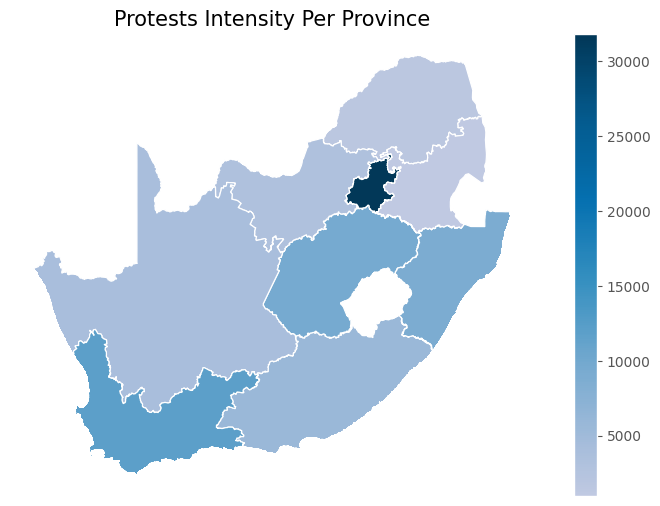

In [292]:
fig, ax = plt.subplots(1, figsize=(10, 6))
ax.axis('off')
ax.set_title('Protests Intensity Per Province', fontdict={'fontsize': '15', 'fontweight' : '3'})
merged.plot(column='Count',
            cmap=new_cmap,
            linewidth=0.9,
            ax=ax,
            edgecolor='1',
            legend=True, missing_kwds={
            "color": "lightgrey",
            "label": "Missing values",},)

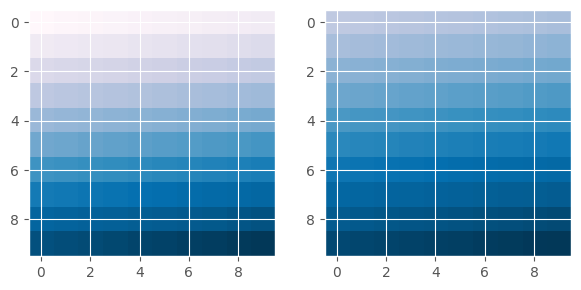

In [291]:
from matplotlib import colors

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list('trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),cmap(np.linspace(minval, maxval, n)))
    return new_cmap
arr = np.linspace(0, 50, 100).reshape((10, 10))
fig, ax = plt.subplots(ncols=2)
cmap = plt.get_cmap('PuBu')
new_cmap = truncate_colormap(cmap, 0.3, 1)
ax[0].imshow(arr, interpolation='nearest', cmap=cmap)
ax[1].imshow(arr, interpolation='nearest', cmap=new_cmap)
plt.show()

In [ ]:
# https://medium.com/@barua.aindriya/visualize-data-on-a-choropleth-map-with-geopandas-and-matplotlib-924cedd8e9cb

### Regressions

#### OLS

In [293]:
X = afro_merged_df[['Income Level Proxy Index', 'Service Delivery Proxy Index', 'Satisfaction Proxy Index']] 
y = afro_merged_df['Number of Protest in 25km radius'] 

regr = linear_model.LinearRegression()
model = regr.fit(X, y)

print('Intercept:', model.intercept_)
print('Coefficients:', model.coef_)

Intercept: 724.1701180024023
Coefficients: [-23.69009881  33.88363101   8.26538266]


In [294]:
X = afro_merged_df[['Income Level Proxy Index', 'Service Delivery Proxy Index', 'Satisfaction Proxy Index']]
X = sm.add_constant(X) # adding a constant

olsmod = sm.OLS(afro_merged_df['Number of Protest in 25km radius'], X).fit()
print(olsmod.summary())

                                   OLS Regression Results                                   
Dep. Variable:     Number of Protest in 25km radius   R-squared:                       0.014
Model:                                          OLS   Adj. R-squared:                  0.013
Method:                               Least Squares   F-statistic:                     23.00
Date:                              Tue, 09 Jan 2024   Prob (F-statistic):           8.75e-15
Time:                                      13:14:53   Log-Likelihood:                -43081.
No. Observations:                              5020   AIC:                         8.617e+04
Df Residuals:                                  5016   BIC:                         8.620e+04
Df Model:                                         3                                         
Covariance Type:                          nonrobust                                         
                                   coef    std err          t      P>|

In [295]:
X = afro_merged_df[['Income Level Proxy Index', 'Service Delivery Proxy Index', 'Satisfaction Proxy Index', 'Eastern Cape', 'Free State', 'Gauteng', 'KwaZulu-Natal', 'Limpopo', 'Mpumalanga', 'North West', 'Northern Cape', 'Western Cape']] 
y = afro_merged_df['Number of Protest in 25km radius'] 

regr = linear_model.LinearRegression()
model = regr.fit(X, y)

print('Intercept:', model.intercept_)
print('Coefficients:', model.coef_)

Intercept: 40.99558827967621
Coefficients: [  -4.82269396   28.23856332   -9.70388576  -16.73510944  -44.2088401
 1863.19468607  469.08569288  -51.40204743  -32.63302838  -23.34334656
  -49.52963424 1024.81824552]


In [296]:
X = afro_merged_df[['Income Level Proxy Index', 'Service Delivery Proxy Index', 'Satisfaction Proxy Index', 'Free State', 'Gauteng', 'KwaZulu-Natal', 'Limpopo', 'Mpumalanga', 'North West', 'Northern Cape', 'Western Cape']]
X = sm.add_constant(X) # adding a constant

olsmod = sm.OLS(afro_merged_df['Number of Protest in 25km radius'], X).fit()
print(olsmod.summary())

                                   OLS Regression Results                                   
Dep. Variable:     Number of Protest in 25km radius   R-squared:                       0.363
Model:                                          OLS   Adj. R-squared:                  0.361
Method:                               Least Squares   F-statistic:                     259.2
Date:                              Tue, 09 Jan 2024   Prob (F-statistic):               0.00
Time:                                      13:14:56   Log-Likelihood:                -41984.
No. Observations:                              5020   AIC:                         8.399e+04
Df Residuals:                                  5008   BIC:                         8.407e+04
Df Model:                                        11                                         
Covariance Type:                          nonrobust                                         
                                   coef    std err          t      P>|

In [297]:
X = afro_merged_df[['Income Level Proxy Index', 'Satisfaction Proxy Index', 'Free State', 'Gauteng', 'KwaZulu-Natal', 'Limpopo', 'Mpumalanga', 'North West', 'Northern Cape', 'Western Cape']]
X = sm.add_constant(X) # adding a constant

olsmod = sm.OLS(afro_merged_df['Number of Protest in 25km radius'], X).fit()
print(olsmod.summary())

                                   OLS Regression Results                                   
Dep. Variable:     Number of Protest in 25km radius   R-squared:                       0.359
Model:                                          OLS   Adj. R-squared:                  0.357
Method:                               Least Squares   F-statistic:                     280.2
Date:                              Tue, 09 Jan 2024   Prob (F-statistic):               0.00
Time:                                      13:14:59   Log-Likelihood:                -42000.
No. Observations:                              5020   AIC:                         8.402e+04
Df Residuals:                                  5009   BIC:                         8.409e+04
Df Model:                                        10                                         
Covariance Type:                          nonrobust                                         
                               coef    std err          t      P>|t|  

In [ ]:
# sns.regplot(x= afro_merged_df['Income Level Proxy Index'], y= afro_merged_df['Number of Protest in 25km radius'])

In [ ]:
# sns.regplot(x= afro_merged_df['Service Delivery Proxy Index'], y= afro_merged_df['Number of Protest in 25km radius'])

In [ ]:
# sns.regplot(x= afro_merged_df['Satisfaction Proxy Index'], y= afro_merged_df['Number of Protest in 25km radius'])

In [ ]:
# df.head()

In [ ]:
# afro_merged_df.head()

In [ ]:
# afro_merged_df.describe()

In [ ]:
# afro_merged_df.corr()

In [ ]:
# correlation = afro_merged_df.corr().round(2)
# plt.figure(figsize = (20,20))
# sns.heatmap(correlation, annot = True, cmap = 'YlOrBr')

In [ ]:
# afro_merged_df.hist(bins=50, figsize=(20,20))
# plt.show()